In [1]:
from spin_lattices import (
    KagomeLattice,
    SpinLattice,
    ChainLattice,
    SquareLattice,
    TriangleLattice,
)
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from pathlib import Path
import networkx as nx
import numpy as np
from typing import Callable
import torch
import numpy.typing as npt
import lattice_symmetries as ls
from typing import Any, Optional, Union, Dict, Tuple
from loguru import logger
from collections import namedtuple
from torch import Tensor
import torch.nn as nn
from misc_utils import make_unpacked_configurations
from vmc_vs_lbfgs_2023_08_02 import LogProbDenseNet
import io
from contextlib import redirect_stderr
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from nqs_playground_helpers import (
    SamplingOptions,
    split_into_batches,
    safe_exp,
    sample_exactly,
    sample_full,
    forward_with_batches,
)
from scipy.sparse import csr_matrix, coo_matrix, diags
from scipy.sparse.csgraph import connected_components
import sys
from kagome_cnn import KagomeCNNRegression
from torch.nn.utils import parameters_to_vector
import time
from slater_determinant import SlaterDeterminant
from vmc_amplitude import (
    compute_log_local_energies,
    find_nbd,
    find_nbd_reference,
    apply_diag_to_basis_states,
    apply_off_diag_to_basis_states,
    true_relsigns,
    almost_true_relsigns,
)
from my_stopwatch import stopwatch
from misc_utils import torch_overlap as find_overlap
from vmc_amplitude import LogProbDenseNetPairwiseXor
import itertools
from misc_utils import differentiable_safe_exp, get_abslargest_terms
from fast_boolean_analysis import fourier_expand, FourierSeries
from lattice_boolean_analysis import (
    LBFFromSpinSystem,
    AmplitudeMedianBinSignalKind,
    AmplitudeSignalKind,
)
import matplotlib.pyplot as plt

2023-08-12 23:16:05.135 | DEBUG    | lattice_symmetries:__init__:50 - Initializing Haskell runtime...
2023-08-12 23:16:05.235 | DEBUG    | lattice_symmetries:__init__:52 - Initializing Chapel runtime...
2023-08-12 23:16:05.414 | DEBUG    | lattice_symmetries:__init__:54 - Setting Python exception handler...
set_python_exception_handler ...


In [15]:
def plot_subsets(subsets, titles, lat: SpinLattice, col_wrap=None):
    if col_wrap is None:
        col_wrap = len(subsets)

    n_rows = int(np.ceil(len(subsets) / col_wrap))
    fig, axes = plt.subplots(
        n_rows, col_wrap, figsize=(col_wrap * 3, n_rows * 3), squeeze=False
    )

    for ax, subset, title in zip(axes.ravel(), subsets, titles):
        lat.plot(spins=subset, ax=ax)
        ax.axis("off")
        ax.set_title(str(title))

    # Turn off axes that aren't used:
    if len(subsets) < n_rows * col_wrap:
        for ax in axes.ravel()[len(subsets) :]:
            ax.axis("off")

    return fig

In [36]:
lattice = KagomeLattice(3, 3)
system = HeisenbergJ1J2(
    lattice=lattice, J1=1, J2=1, ground_state_cache_dir=Path("groundstates")
)
series = fourier_expand(
    LBFFromSpinSystem(system=system, eigenstate=0, kind=AmplitudeSignalKind())
)
reprs = series.signal.lattice.get_fourier_basis_data().reprs
coeffs = series.coeffs

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


In [34]:
series.how_many_terms_to_achieve_score(0.9, "value_overlap")

(True,
 15043,
 array([-0.00044424, -0.0003837 ,  0.00072747, ...,  0.00072747,
        -0.0003837 , -0.00044424]))

In [35]:
15043 / len(series.coeffs)

0.057384490966796875

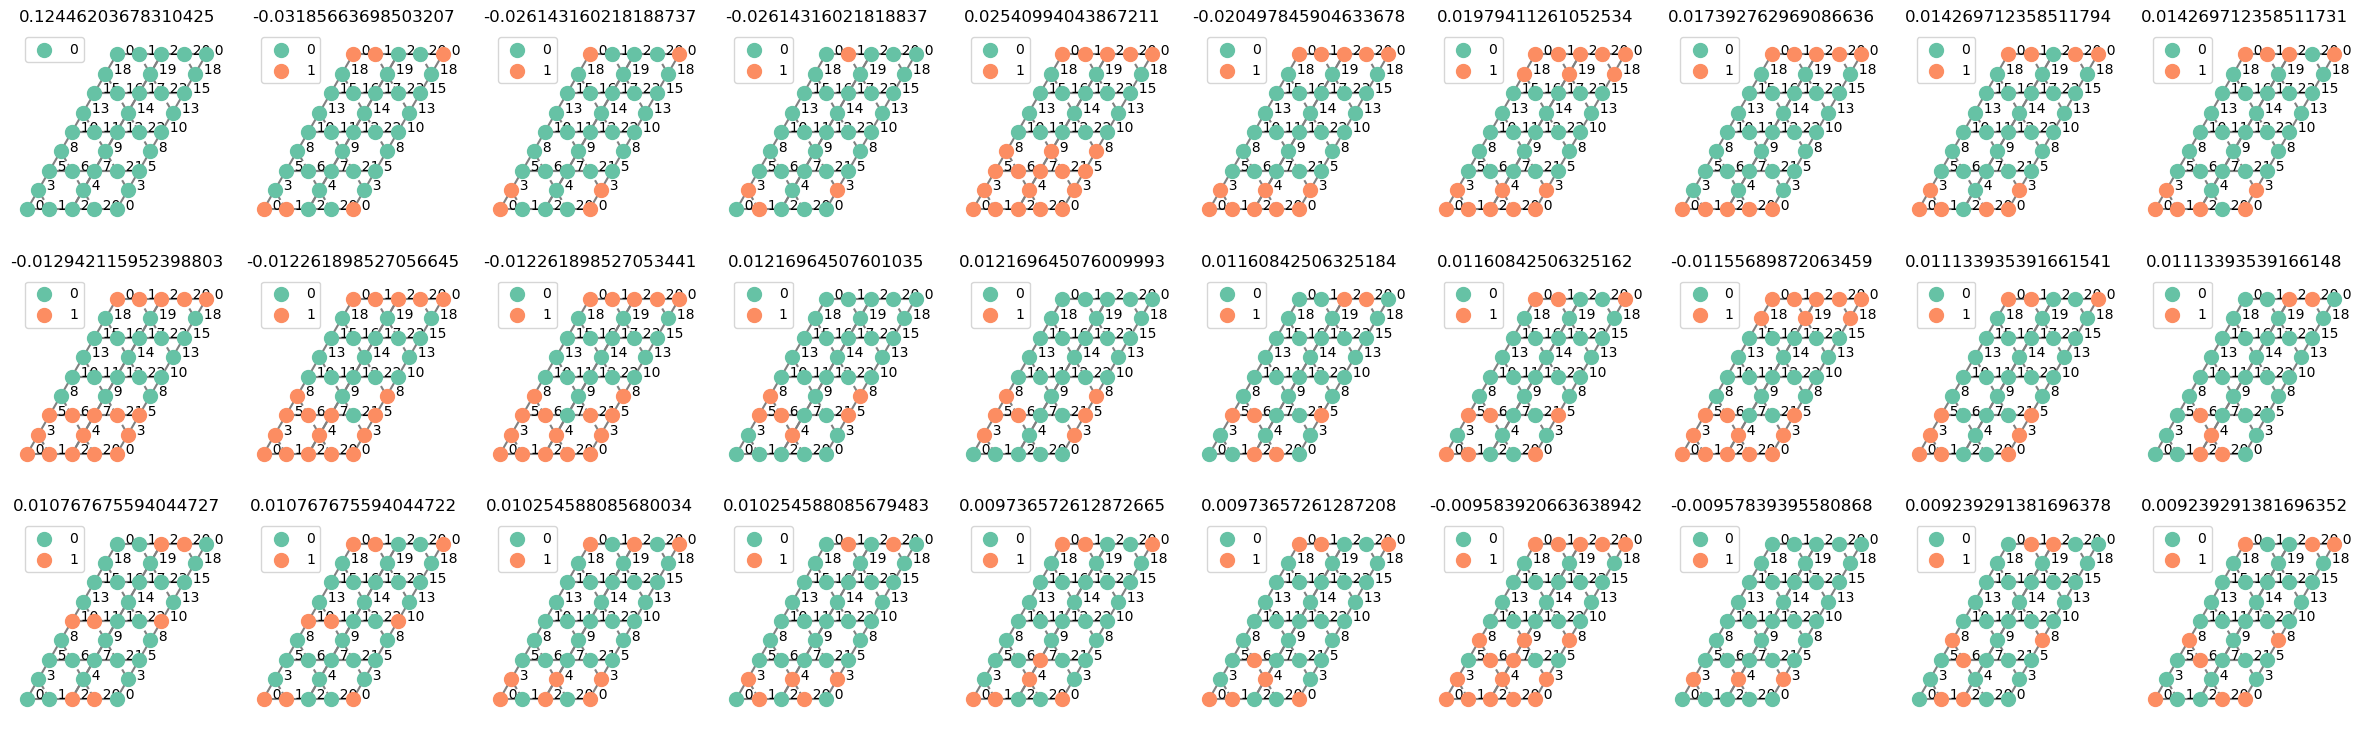

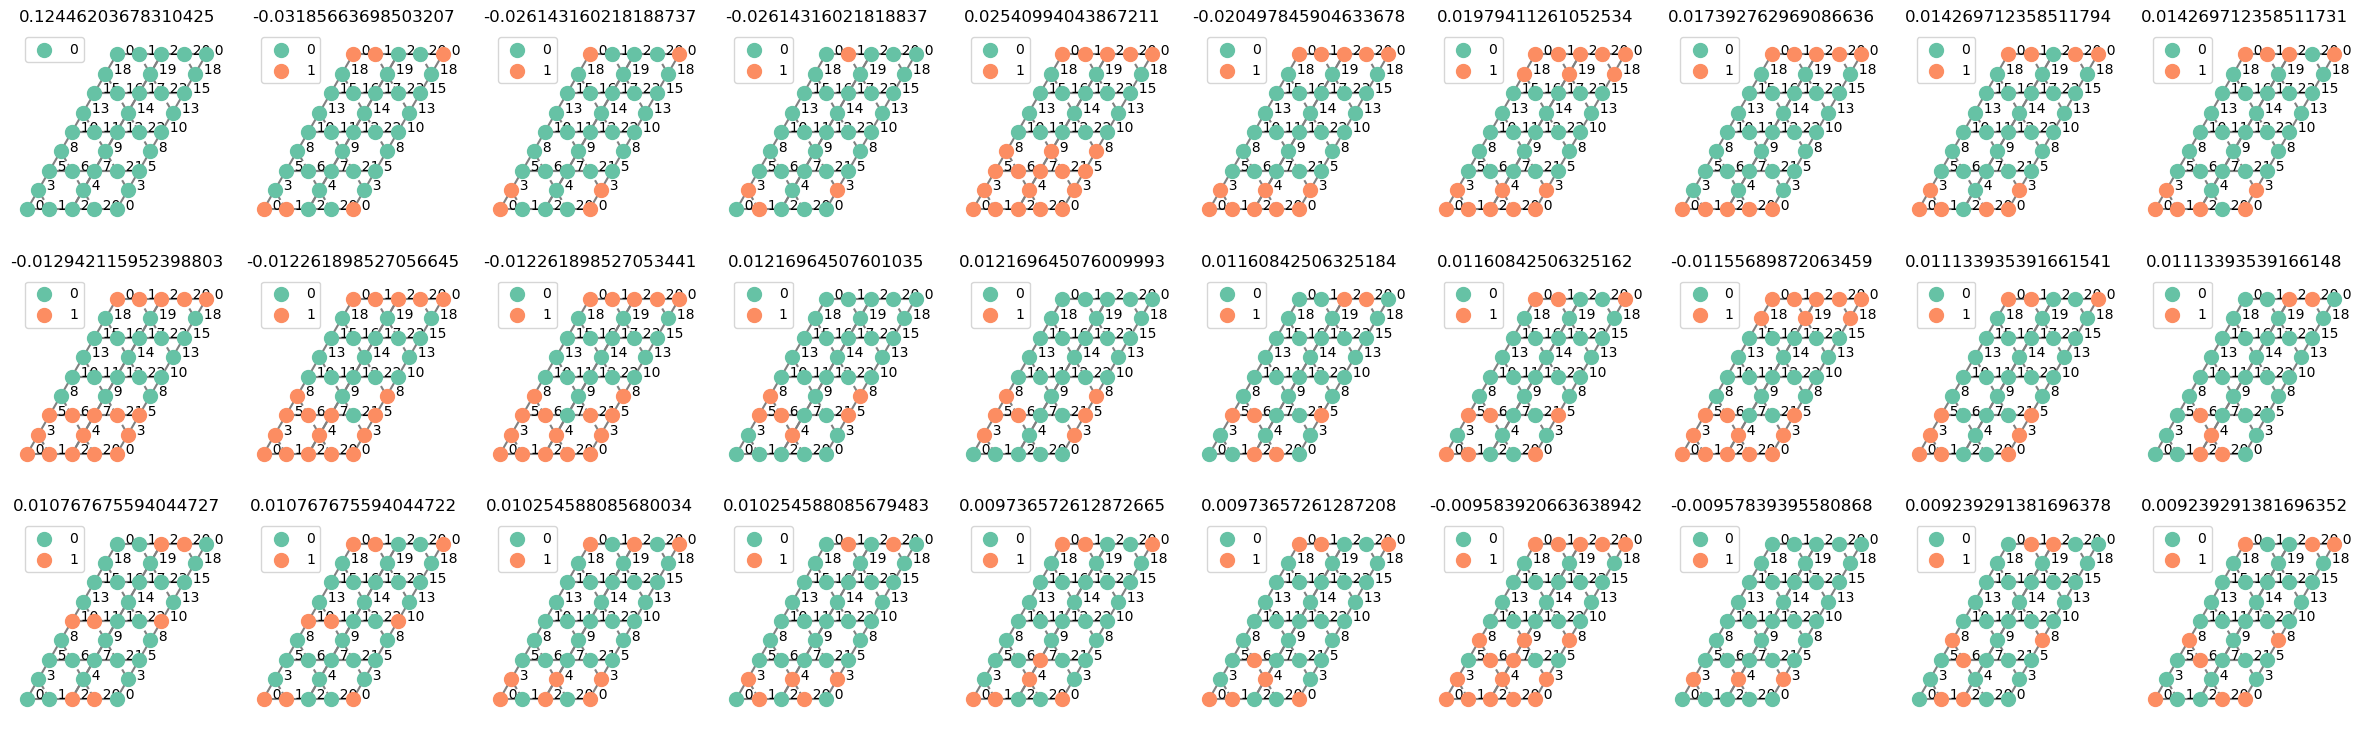

In [26]:
idxs, coeffs = get_abslargest_terms(coeffs[reprs], 30)
subsets = reprs[idxs]

plot_subsets(subsets, coeffs, lattice, col_wrap=10)

In [3]:
lattice = KagomeLattice(2, 3)
system = HeisenbergJ1J2(
    lattice=lattice,
    J1=1,
    J2=0.5,
    ground_state_cache_dir=Path("groundstates"),
    use_symmetries=False,
    spin_inversion=None,
)
matrix, states = find_nbd(system.hamiltonian, system.basis.states[:100])
matrix_ref, states_ref = find_nbd_reference(
    system.hamiltonian, system.basis.states[:100]
)
assert np.allclose(matrix.toarray(), matrix_ref.toarray())
assert np.allclose(states, states_ref)

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
/vol/tcm10/ischurov/frustrations-eda/vmc_amplitude.py:100: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs_data = np.concatenate(coeff_rows).astype(np.float64)


In [2]:
def test_full_energy():
    lattice = ChainLattice(10)
    system = HeisenbergJ1J2(lattice, J1=1, ground_state_cache_dir=Path("groundstates"))
    true_energy, ground_state = system.get_eigenstates(1)
    true_energy = true_energy[0]
    ground_state = ground_state[:, 0]

    states = system.canonical_basis.states

    def true_logprob(states: npt.NDArray[np.uint64]) -> npt.NDArray[np.float64]:
        return 2 * np.log(np.abs(system.get_ground_state_coeffs(states)))  # type ignore

    E_loc = np.exp(
        compute_log_local_energies(
            system.hamiltonian,
            states,
            true_relsigns(system),
            true_logprob,
        )[0]
    )

    assert np.isclose(E_loc @ (ground_state**2), true_energy)


test_full_energy()

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-08-10 14:34:26.060 | INFO     | vmc_amplitude:compute_log_local_energies:355 - log_abs_psi_nbd.min()=-7.638596975690589, log_abs_psi_nbd.max()=-1.1025663560486594
2023-08-10 14:34:26.061 | INFO     | vmc_amplitude:compute_log_local_energies:356 - abs_psi_nbd.min()=0.0014502336180339669, abs_psi_nbd.max()=1.0
2023-08-10 14:34:26.061 | INFO     | vmc_amplitude:compute_log_local_energies:356 - abs_psi_nbd.min()=0.0014502336180339669, abs_psi_nbd.max()=1.0


In [3]:
def test_local_E_loc_consistency():
    lattice = ChainLattice(10)
    system = HeisenbergJ1J2(lattice, J1=1, ground_state_cache_dir=Path("groundstates"))
    system.get_eigenstates(1)

    def true_logprob(states: npt.NDArray[np.uint64]) -> npt.NDArray[np.float64]:
        return 2 * np.log(np.abs(system.get_ground_state_coeffs(states)))  # type ignore

    E_loc_full = np.exp(
        compute_log_local_energies(
            system.hamiltonian,
            system.canonical_basis.states,
            true_relsigns(system),
            true_logprob,
        )[0]
    )

    for size in range(1, len(system.canonical_basis.states), 10):
        print(f"{size=}", end="...")
        sampled_states = np.random.choice(system.canonical_basis.states, size=size)
        E_loc_sampled = np.exp(
            compute_log_local_energies(
                system.hamiltonian,
                sampled_states,
                true_relsigns(system),
                true_logprob,
            )[0]
        )

        assert np.allclose(
            E_loc_full[np.searchsorted(system.canonical_basis.states, sampled_states)],
            E_loc_sampled,
        )

        print("ok")


test_local_E_loc_consistency()

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-08-10 14:34:26.945 | INFO     | vmc_amplitude:compute_log_local_energies:355 - log_abs_psi_nbd.min()=-7.638596975690589, log_abs_psi_nbd.max()=-1.1025663560486594
2023-08-10 14:34:26.946 | INFO     | vmc_amplitude:compute_log_local_energies:356 - abs_psi_nbd.min()=0.0014502336180339669, abs_psi_nbd.max()=1.0
2023-08-10 14:34:26.951 | INFO     | vmc_amplitude:compute_log_local_energies:355 - log_abs_psi_nbd.min()=-5.844266422119002, log_abs_psi_nbd.max()=-3.4949712808846525
2023-08-10 14:34:26.951 | INFO     | vmc_amplitude:compute_log_local_energies:356 - abs_psi_nbd.min()=0.09543640770201116, abs_psi_nbd.max()=1.0
2023-08-10 14:34:26.956 | INFO     | vmc_amplitude:compute_log_local_energies:355 - log_abs_psi_nbd.min()=-7.638596975690589, log_abs_psi_nbd.max()=-1.1025663560486594
2023-08-10 14:34:26.957 | INFO     | vmc_amplitude:compute_log_local_energies:356 - abs_psi_nbd.min()=0.0014502336180339669, abs_psi_nbd.max()=1

2023-08-10 14:34:26.990 | INFO     | vmc_amplitude:compute_log_local_energies:355 - log_abs_psi_nbd.min()=-7.638596975690547, log_abs_psi_nbd.max()=-1.1025663560486594
2023-08-10 14:34:26.990 | INFO     | vmc_amplitude:compute_log_local_energies:356 - abs_psi_nbd.min()=0.0014502336180340287, abs_psi_nbd.max()=1.0
2023-08-10 14:34:26.995 | INFO     | vmc_amplitude:compute_log_local_energies:355 - log_abs_psi_nbd.min()=-7.638596975690589, log_abs_psi_nbd.max()=-1.1025663560486594
2023-08-10 14:34:26.996 | INFO     | vmc_amplitude:compute_log_local_energies:356 - abs_psi_nbd.min()=0.0014502336180339669, abs_psi_nbd.max()=1.0
2023-08-10 14:34:27.002 | INFO     | vmc_amplitude:compute_log_local_energies:355 - log_abs_psi_nbd.min()=-7.638596975690589, log_abs_psi_nbd.max()=-1.1025663560486594
2023-08-10 14:34:27.003 | INFO     | vmc_amplitude:compute_log_local_energies:356 - abs_psi_nbd.min()=0.0014502336180339669, abs_psi_nbd.max()=1.0
2023-08-10 14:34:27.008 | INFO     | vmc_amplitude:comp

size=1...ok
size=11...ok
size=21...ok
size=31...ok
size=41...ok
size=51...ok
size=61...ok
size=71...ok
size=81...ok
size=91...ok
size=101...ok
size=111...ok
size=121...ok
size=131...ok
size=141...ok
size=151...ok
size=161...ok
size=171...ok
size=181...ok
size=191...ok
size=201...ok
size=211...ok
size=221...ok
size=231...ok
size=241...ok
size=251...ok


In [3]:
# Calculate the gradient norms
# FROM: GPT-4
def get_gradient_norm(parameters):
    grads = []
    for p in parameters:
        if p.grad is not None:
            grads.append(p.grad)
    grad_vector = parameters_to_vector(grads)
    return torch.linalg.norm(grad_vector)


# END FROM

In [4]:
stopwatch.reset()

# n_samples = 48620
n_samples = 10000
lr = 1e-3
momentum = 0.0
batch_size = 8092
sign_noise = 0.0
weight_decay = 0
annealing_steps = 0  # 400
initial_temp = 3
sampling_mode = "exact"

# lattice = TriangleLattice(6, 4)
lattice = KagomeLattice(2, 3)
# lattice = ChainLattice(10)
system = HeisenbergJ1J2(
    lattice=lattice,
    J1=1,
    J2=1,
    ground_state_cache_dir=Path("groundstates"),
    use_symmetries=False,
    spin_inversion=None,
)
true_energy, _ = system.get_eigenstates(1)
true_energy = true_energy[0]

if len(system.canonical_basis.states) > 50000:
    eval_set = np.random.choice(system.canonical_basis.states, 50000, replace=False)
else:
    eval_set = system.canonical_basis.states

pairs = tuple(
    map(np.array, zip(*itertools.combinations(range(system.number_spins), 2)))
)
# pairs = tuple(map(np.array, zip(*system.lattice.edges_to_kind.keys())))

log_prob_fn = LogProbDenseNetPairwiseXor(
    system, n_hidden=512, hidden_layers=1, xor_pairs=pairs
)
# log_prob_fn = SlaterAbs(
#     system.lattice,
#     system.canonical_basis,
#     sign_cache_dir=Path("signs_cache"),
#     initialization="randn",
# )

# log_prob_fn = KagomeCNNRegression(system.lattice, hidden_channels1=32, hidden_channels2=64)
# optimizer = torch.optim.SGD(log_prob_fn.parameters(), lr=lr, momentum=momentum)
optimizer = torch.optim.Adam(log_prob_fn.parameters(), lr=lr, weight_decay=weight_decay)

true_amplitudes = torch.from_numpy(
    np.abs(system.get_ground_state_coeffs(eval_set)).astype(np.float32)
)
relsigns_fn = almost_true_relsigns(system, eps=sign_noise)

writer = SummaryWriter(
    log_dir=(
        f"experiments/{datetime.now().strftime('%Y_%m_%d')}_vmc/{datetime.now().strftime('%H_%M_%S')}"
    )
)

sampling_time = 0
local_energies_time = 0
optimization_time = 0
evaluation_time = 0

for step in range(10000):
    sampling_time_tick = time.time()
    if sampling_mode == "exact":
        states, log_probs, all_probs = sample_exactly(
            log_prob_fn,
            system.basis,
            SamplingOptions(
                number_samples=n_samples,
                number_chains=1,
                mode="exact",
                sweep_size=1,
                number_discarded=0,
            ),
            return_all_probs=True,
        )
        states, weights = torch.unique(states.view(-1), return_counts=True)
        weights = weights.float() / torch.sum(weights)

    elif sampling_mode == "full":
        states, log_probs, _extra = sample_full(
            log_prob_fn,
            system.basis,
            SamplingOptions(
                number_samples=1,
                number_chains=1,
                mode="full",
                sweep_size=1,
                number_discarded=0,
            ),
        )
        states = states.view(-1)
        weights = _extra["weights"].view(-1)
        all_probs = weights
    else:
        raise ValueError(f"Unknown sampling mode: {sampling_mode}")
    sampling_time += time.time() - sampling_time_tick

    ipr = torch.sum(all_probs**2)
    writer.add_scalar("loss/ipr", ipr, step)

    local_energies_time_tick = time.time()
    log_E_loc, *_ = compute_log_local_energies(
        system.hamiltonian,
        states.detach().numpy(),
        relsigns_fn=relsigns_fn,
        log_prob_fn=lambda s: log_prob_fn(torch.from_numpy(s.astype(np.int64)))
        .view(-1)
        .detach()
        .numpy(),
    )
    log_E_loc = torch.from_numpy(log_E_loc).to(torch.complex64)
    local_energies_time += time.time() - local_energies_time_tick

    # states = states.view(-1, states.size(-1))
    # log_probs = log_probs.view(-1)
    # weights = weights.view(-1)

    # Compute output gradient
    sampling_time_tick = time.time()

    with torch.no_grad():
        weighted_E_loc = torch.exp(log_E_loc + np.log(weights)).real
        grad = 4 * (weighted_E_loc - weighted_E_loc.sum() * weights)

        # coeff 4 is due to: 2 from formula, 2 due to we are working with log probs
        # instead of log amplitudes

        # grad = 4 * (E - E @ weights) * weights

        grad = grad.view(-1, 1)
        grad_norm = torch.linalg.norm(grad)
        #    logger.info("‖∇E‖₂ = {}", grad_norm)
        writer.add_scalar("loss/‖∇E‖₂", grad_norm, step)
        writer.add_scalar("loss/E_variance", grad_norm / n_samples, step)

        # Calculate full energy
        # if sampling_mode == "exact":
        E = torch.exp(log_E_loc).real
        E_full = E @ safe_exp(log_prob_fn(states).view(-1), normalise=True)
        writer.add_scalar("loss/E_full_delta", E_full - torch.tensor(true_energy), step)
        logger.info("E_full_delta = {}", E_full - torch.tensor(true_energy))

    optimizer.zero_grad()
    # batch_size = self.config.inference_batch_size

    # Computing gradients for the amplitude network
    # logger.info("Computing gradients...")
    # if _should_optimize(self.config.amplitude):
    #     self.config.amplitude.train()
    forward_fn = log_prob_fn
    for states_chunk, grad_chunk in split_into_batches(
        (states.view(-1, 1), grad), batch_size
    ):
        output = forward_fn(states_chunk.view(-1))
        output.backward(grad_chunk, retain_graph=True)

        if step < annealing_steps:
            temp = initial_temp * (1 - step / annealing_steps)
            probs = differentiable_safe_exp(output, normalise=True)
            entropy = -torch.sum(probs * torch.log(probs))
            entropy_loss = -temp * entropy
            entropy_loss.backward()

    full_gradient_norm = get_gradient_norm(forward_fn.parameters())
    writer.add_scalar("loss/full_gradient_norm", full_gradient_norm, step)

    optimizer.step()
    optimization_time += time.time() - sampling_time_tick

    evaluation_time_tick = time.time()
    predicted_amplitudes = safe_exp(log_prob_fn(eval_set) * 0.5)

    overlap = find_overlap(true_amplitudes, predicted_amplitudes.view(-1))
    writer.add_scalar("overlap", overlap, step)
    logger.info(
        f"{step}: overlap = {overlap:.3f}, ‖∇E‖₂ = {grad_norm:.3f}, full_gradient_norm = {full_gradient_norm:.3f}"
    )
    evaluation_time += time.time() - evaluation_time_tick

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-08-12 23:19:00.601 | INFO     | vmc_amplitude:compute_log_local_energies:355 - log_abs_psi_nbd.min()=-0.4384638, log_abs_psi_nbd.max()=0.35378027
2023-08-12 23:19:00.606 | INFO     | vmc_amplitude:compute_log_local_energies:356 - abs_psi_nbd.min()=0.45282748, abs_psi_nbd.max()=1.0
2023-08-12 23:19:00.656 | INFO     | __main__:<module>:148 - E_full_delta = 18.108058260485763
2023-08-12 23:19:01.058 | INFO     | __main__:<module>:182 - 0: overlap = 0.469, ‖∇E‖₂ = 0.576, full_gradient_norm = 25.781
2023-08-12 23:19:02.003 | INFO     | vmc_amplitude:compute_log_local_energies:355 - log_abs_psi_nbd.min()=-0.5171639, log_abs_psi_nbd.max()=0.4019949
2023-08-12 23:19:02.006 | INFO     | vmc_amplitude:compute_log_local_energies:356 - abs_psi_nbd.min()=0.3988544, abs_psi_nbd.max()=1.0
2023-08-12 23:19:02.056 | INFO     | __main__:<module>:148 - E_full_delta = 16.761839197680587
2023-08-12 23:19:02.429 | INFO     | __main__:<module>

KeyboardInterrupt: 